# Tests for FrugalityScore Python package

In [18]:
import numpy as np
import frugalityscore as fscore
import matplotlib.pyplot as plt
%matplotlib inline

In [12]:
# Initialize global variables for testing
num_points = 1000
plot = True
defuzz = "mom"

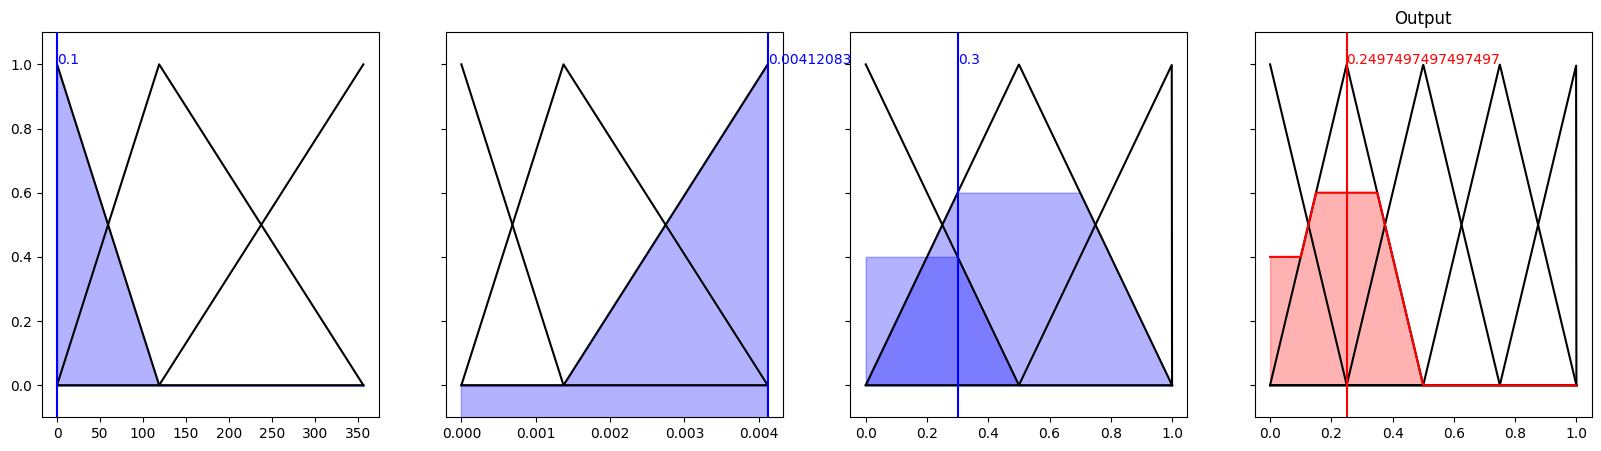

Score : 0.2497497497497497


In [13]:
# Test with machine learning frugality score system
scoresys = fscore.system.MLFrugalityScore(path="../src/data")
print("Score :", scoresys.interpret(input=[0.1,0.1,0.3], plot=plot, defuzz=defuzz))

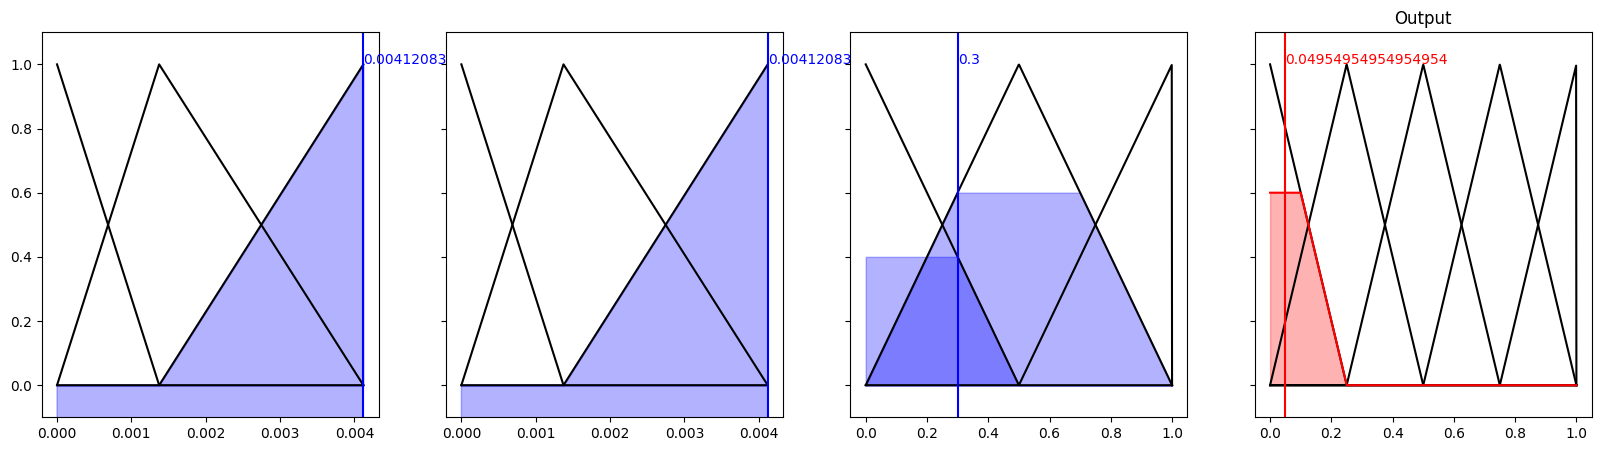

Score : 0.04954954954954954


In [15]:
# Test with machine learning frugality score system
scoresys = fscore.system.MLFrugalityScore(path="../src/data", scale="s", scale_inference="s", system="DEFAULT")
print("Score :", scoresys.interpret(input=[0.1,0.1,0.3], plot=plot, defuzz=defuzz))

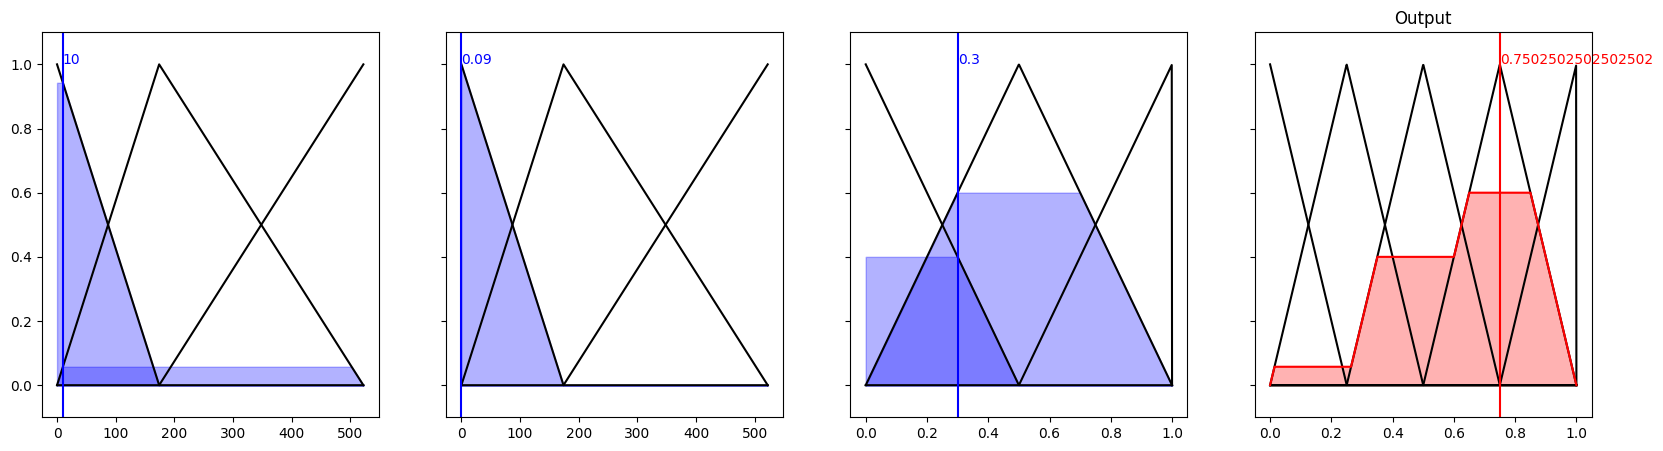

Score : 0.7502502502502502


In [16]:
# Test with machine learning frugality score system
scoresys = fscore.system.MLFrugalityScore(path="../src/data", reference="fridge")
print("Score :", scoresys.interpret(input=[10,0.09,0.3], plot=plot, defuzz=defuzz))

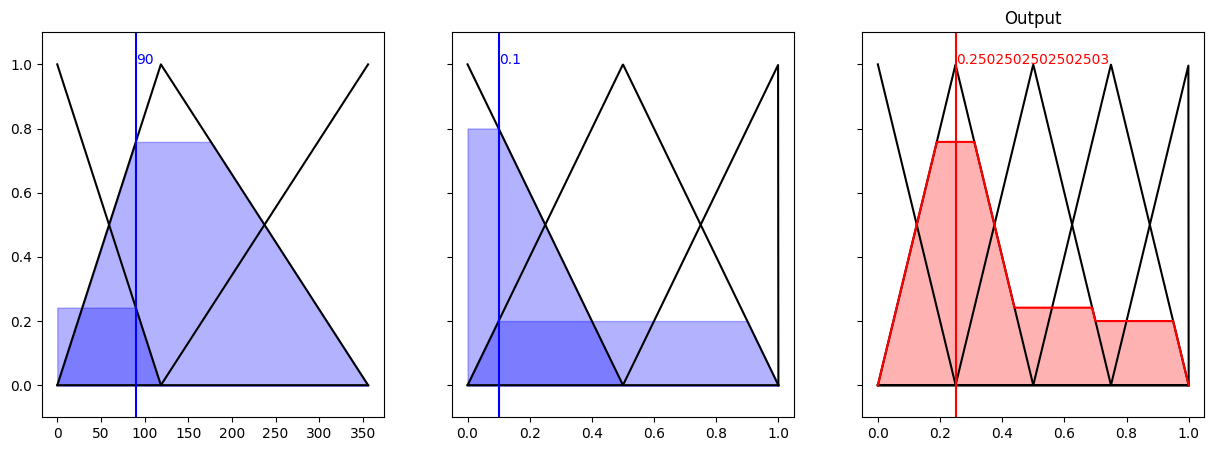

Score : 0.2502502502502503


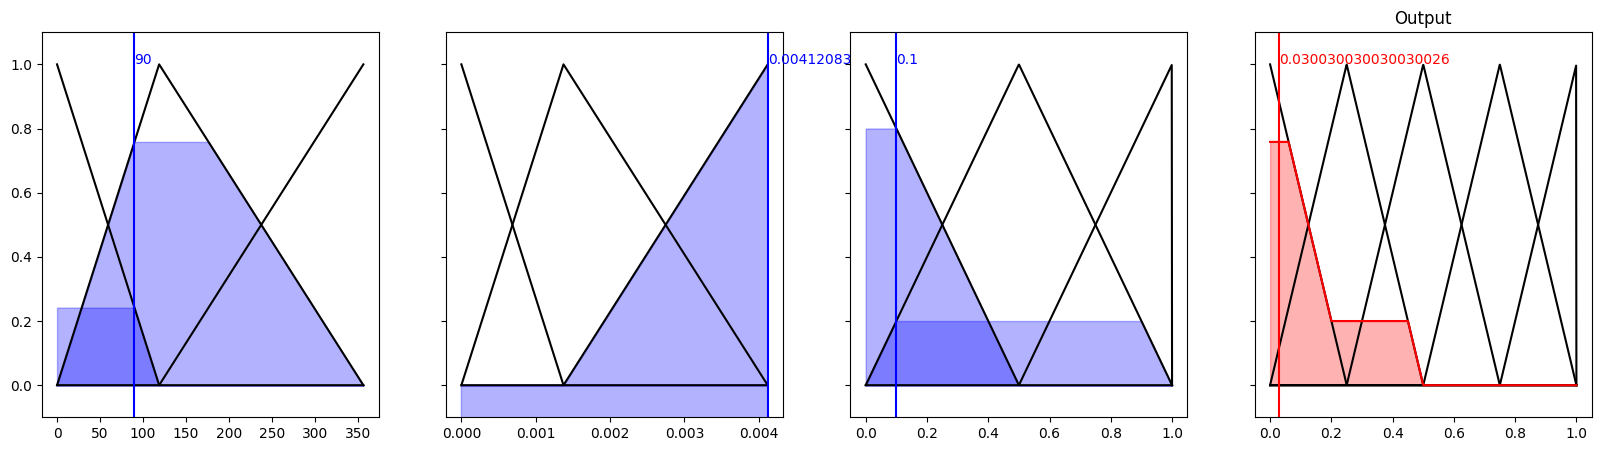

Score : 0.030030030030030026


In [17]:
# Test with default frugality score system
scoresys = fscore.system.FrugalityScore(trainable=False, 
                                        gpu=False, 
                                        cores=1, 
                                        memory=2, 
                                        system="DEFAULT", 
                                        path="../src/data", 
                                        reference="system", 
                                        scale="d", 
                                        metric='accuracy')
print("Score :", scoresys.interpret(input=[90,0.1], plot=plot, defuzz=defuzz))
scoresys = fscore.system.FrugalityScore(trainable=True, 
                                        gpu=False, 
                                        cores=1, 
                                        memory=2, 
                                        system="DEFAULT", 
                                        path="../src/data", 
                                        reference="system", 
                                        scale="d", 
                                        scale_inference="s", 
                                        metric='accuracy')
print("Score :", scoresys.interpret(input=[90,0.1,0.1], plot=plot, defuzz=defuzz))


In [6]:
# Custom system
energy_train = fscore.system.FuzzyVariable(min=0, max=1000, functions=['trimf','trimf','trapmf'], params=[[0,0,25],[0,25,50],[25,50,1000,1000]], num_points=num_points)
energy_test = fscore.system.FuzzyVariable(min=0, max=10, functions=['trimf','trimf','trapmf'], params=[[0,0,2.5],[0,2.5,5],[2.5,5,10,10]], num_points=num_points)
performance =  fscore.system.FuzzyVariable(min=0, max=1, functions=['trimf','trimf','trimf'], params=[[0,0,0.5],[0,0.5,1],[0.5,1,1]], num_points=num_points)
score =  fscore.system.FuzzyVariable(min=0, max=1, functions=['trimf','trimf','trimf','trimf','trimf'], params=[[0,0,0.25],[0,0.25,0.5],[0.25,0.5,0.75],[0.5,0.75,1],[0.75,1,1]], num_points=num_points)

rules = np.array([[[2,3,4],
                   [1,2,3],
                   [0,1,2]],
                  [[1,2,3],
                   [0,1,2],
                   [0,0,1]],
                  [[0,2,3],
                   [0,0,2],
                   [0,0,0]]])

scoresys = fscore.system.FuzzySystem(invar=[energy_train,energy_test,performance], outvar=score, rules=rules)

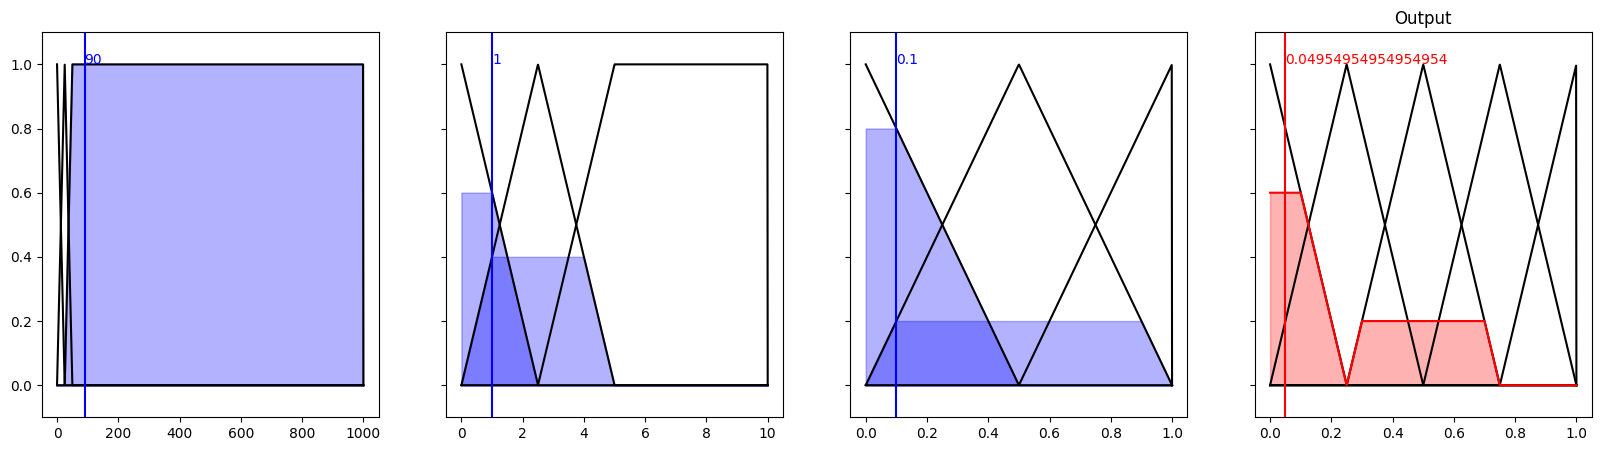

Score : 0.04954954954954954


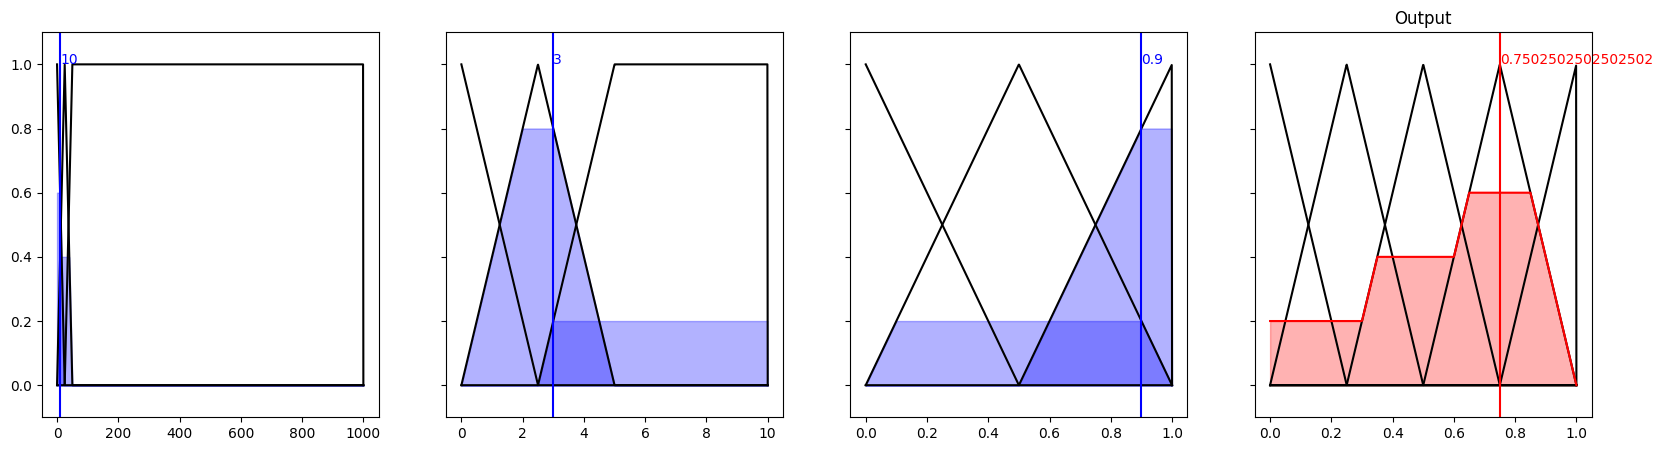

Score : 0.7502502502502502


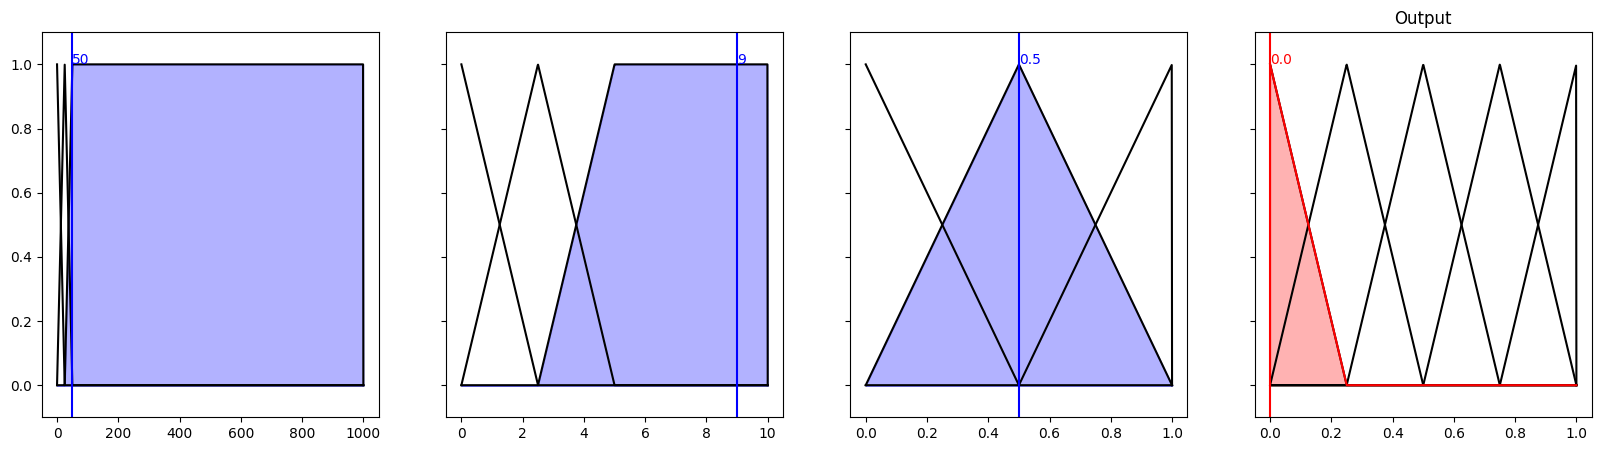

Score : 0.0


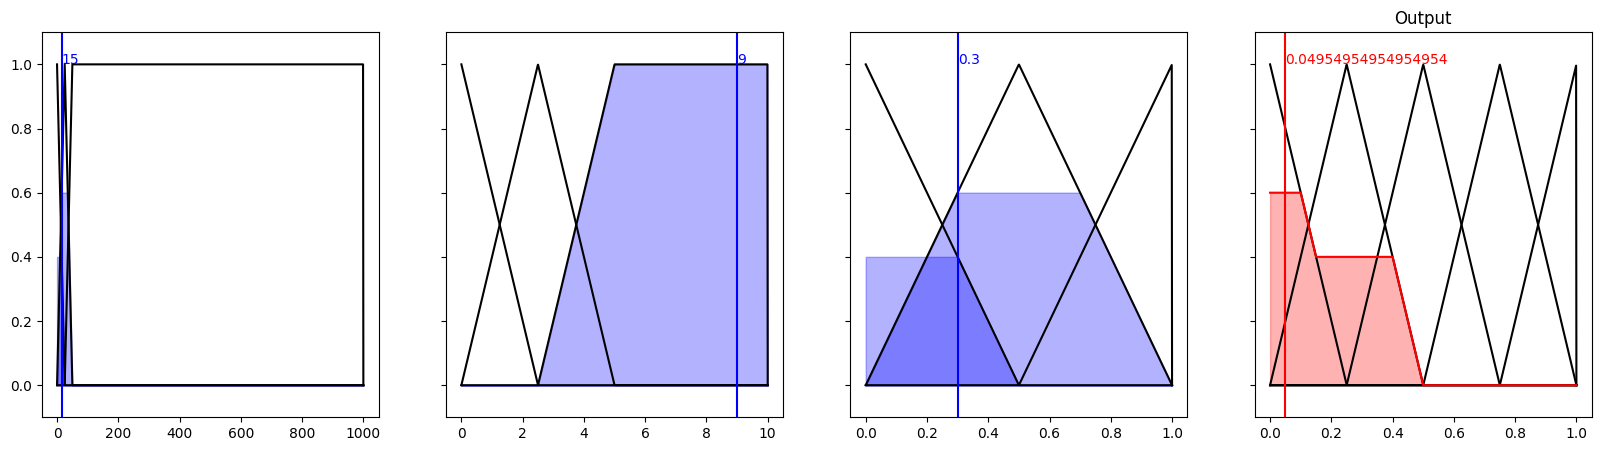

Score : 0.04954954954954954


In [7]:
# Test with custom system
print("Score :",scoresys.interpret(input=[90,1,0.1], plot=plot, defuzz=defuzz))
print("Score :",scoresys.interpret(input=[10,3,0.9], plot=plot, defuzz=defuzz))
print("Score :",scoresys.interpret(input=[50,9,0.5], plot=plot, defuzz=defuzz))
print("Score :",scoresys.interpret(input=[15,9,0.3], plot=plot, defuzz=defuzz))

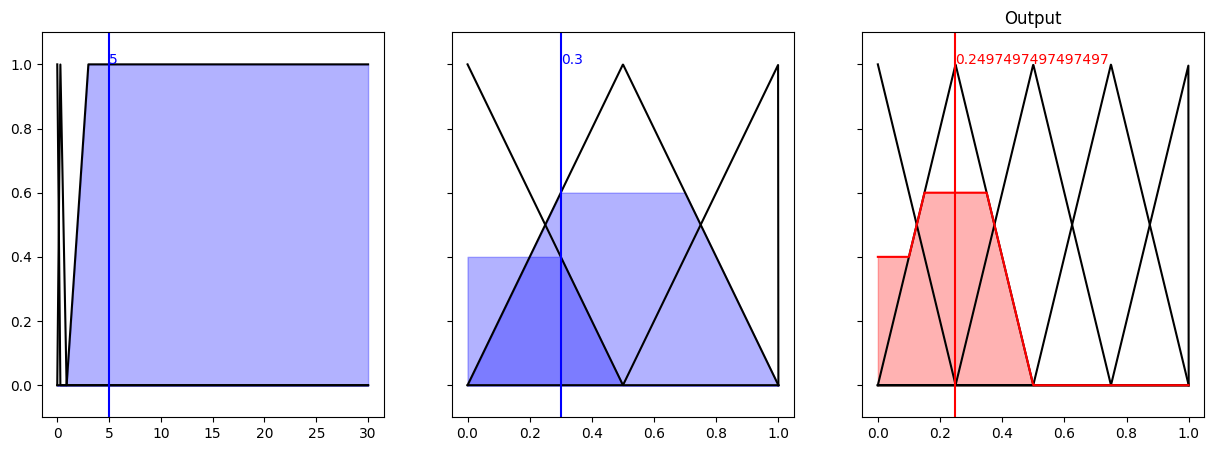

Score : 0.2497497497497497


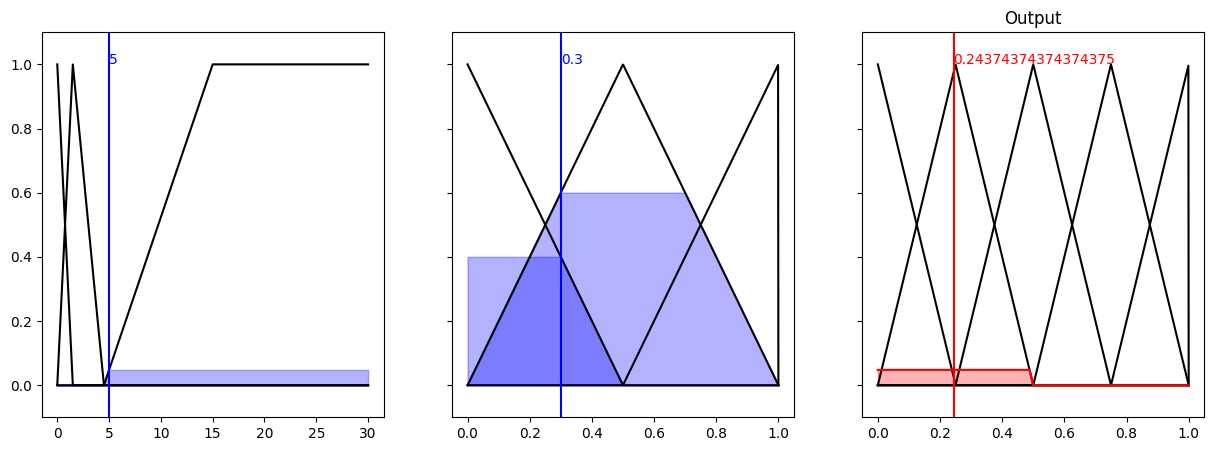

Score : 0.24374374374374375


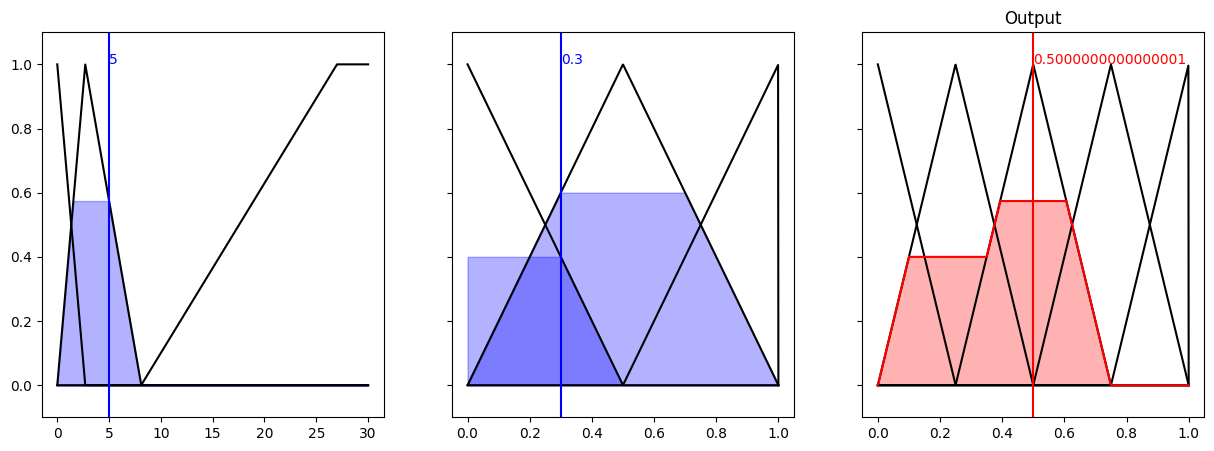

Score : 0.5000000000000001


In [8]:
plot=True
defuzz="mom"
scoresys = fscore.system.TrackingFrugalityScore(path="../src/data", epoch=1, max_epoch=10, reference="smartphone")
print("Score :", scoresys.interpret(input=[5,0.3], plot=plot, defuzz=defuzz))

scoresys = fscore.system.TrackingFrugalityScore(path="../src/data", epoch=5, max_epoch=10, reference="smartphone")
print("Score :", scoresys.interpret(input=[5,0.3], plot=plot, defuzz=defuzz))

scoresys = fscore.system.TrackingFrugalityScore(path="../src/data", epoch=9, max_epoch=10, reference="smartphone")
print("Score :", scoresys.interpret(input=[5,0.3], plot=plot, defuzz=defuzz))